In [25]:
from IPython.display import Image

# Conv NN의 실습 

## 1) LeNet을 사용한 CIFAR-10 학습 

- 

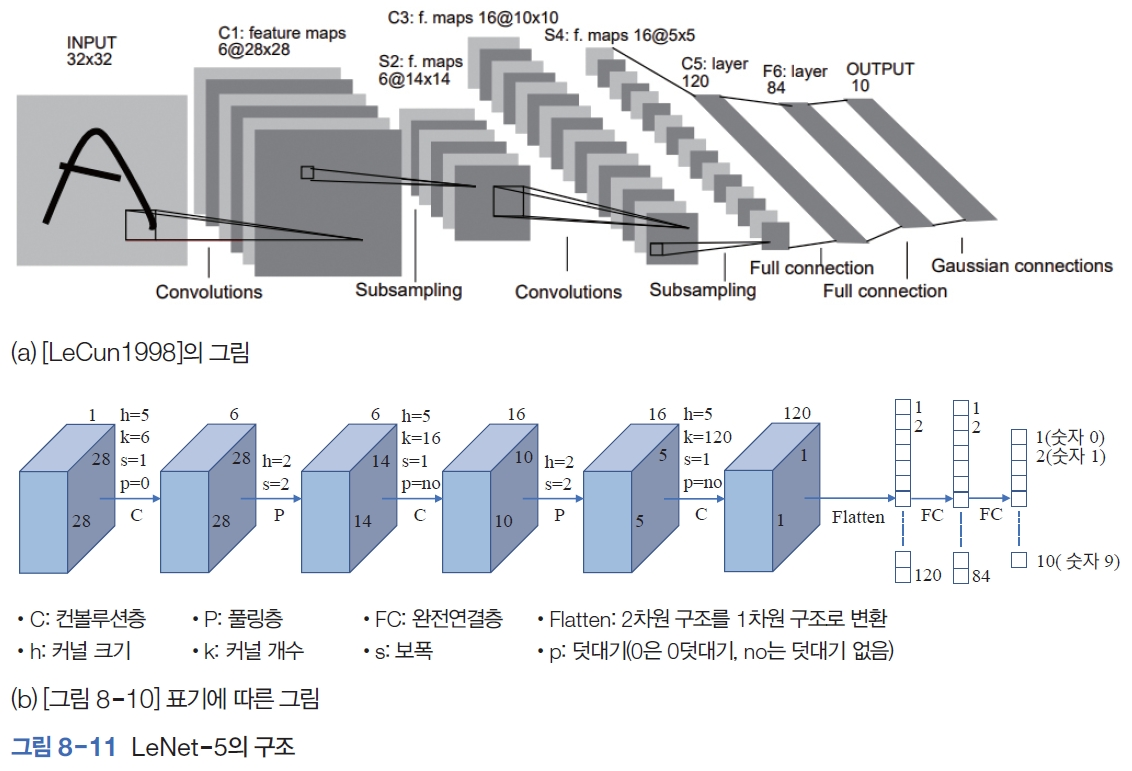

In [3]:
Image("그림 8-11.jpg", width=720)

# 구조 
- 기본적으로 MNIST LeNet-5를 그대로 따름.
- MNIST는 흑백 (1 채널), CIFAR-10은 RGB 3 채널
- MNIST해상도는 28x28 (CNN계층이후에 1x1), CIFAR1-10은 32x32 (CNN 이후에 5x5)

# 관찰사항
- Conv2d와 MaxPool2d를 거치면서 이미지의 가로/세로 해상도가 어떻게 줄어드는지, 반대로 채널(Feature map)은 어떻게 늘어나는지 
     - 특히 x.view(-1, 16 * 5 * 5) 부분에서 왜 16*5*5라는 숫자가 나왔는지
- Optimizer 변경 실험
   - optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)로 바꿔보고 Adam과 수렴 속도를 비교.
-  데이터 증강(Augmentation):
    - transforms 리스트에 transforms.RandomHorizontalFlip()을 추가했을 때 정확도가 어떻게 변하는지 확인 (과적합 방지)

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # CIFAR-10은 RGB 3채널이므로 입력을 3으로 설정
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5) # InCh 3 => OutCh 6, kernel=5x5, stride=1
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)  # InCh 6 => OutCh 16, kernel=5x5, stride=1
        self.fc1   = nn.Linear(16*5*5, 120)  # FC1  : CIFAR는 32x32 
        self.fc2   = nn.Linear(120, 84)  # FC2
        self.fc3   = nn.Linear(84, 10)  # FC3 final

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # max pooling
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)  # max pooling 
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [6]:
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. 하이퍼파라미터 설정 및 데이터 준비
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
batch_size = 64
learning_rate = 0.001
num_epochs = 10

# CIFAR-10 데이터 전처리 (정규화 포함)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [07:30<00:00, 378kB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


Files already downloaded and verified


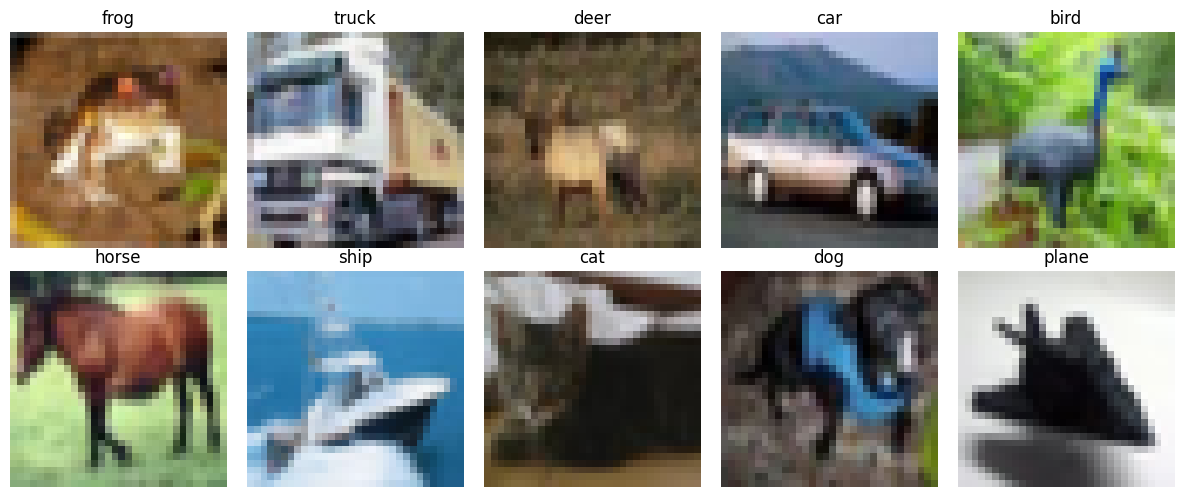

In [8]:
import matplotlib.pyplot as plt

# 데이터를 불러올 때 정규화를 하지 않은 상태로 가져와야 시각적으로 올바르게 보입니다.
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4, shuffle=True)

# 클래스 이름 정의
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    # 이미지를 넘파이 배열로 변환
    npimg = img.numpy()
    # (Channel, Height, Width) -> (Height, Width, Channel)로 축 변경
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# 데이터셋에서 각 클래스별 샘플 하나씩 찾아보기
sample_images = []
sample_labels = []
found_classes = set()

for images, labels in trainset:
    label = labels
    if label not in found_classes:
        sample_images.append(images)
        sample_labels.append(label)
        found_classes.add(label)
    if len(found_classes) == 10:
        break

# 2x5 그리드로 시각화
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # 찾아둔 샘플들 중 인덱스에 맞는 이미지 출력
    img_display = np.transpose(sample_images[i].numpy(), (1, 2, 0))
    plt.imshow(img_display)
    plt.title(classes[sample_labels[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
model = LeNet5().to(device)

# 3. 손실 함수 및 Optimizer 설정
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 4. 학습 (Training Loop)
print("Starting Training...")
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if (i+1) % 200 == 0:
            print(f'[Epoch {epoch + 1}, Step {i + 1}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0

print("Finished Training")

Starting Training...
[Epoch 1, Step 200] loss: 1.983
[Epoch 1, Step 400] loss: 1.704
[Epoch 1, Step 600] loss: 1.576
[Epoch 2, Step 200] loss: 1.419
[Epoch 2, Step 400] loss: 1.374
[Epoch 2, Step 600] loss: 1.349
[Epoch 3, Step 200] loss: 1.279
[Epoch 3, Step 400] loss: 1.225
[Epoch 3, Step 600] loss: 1.216
[Epoch 4, Step 200] loss: 1.154
[Epoch 4, Step 400] loss: 1.149
[Epoch 4, Step 600] loss: 1.144
[Epoch 5, Step 200] loss: 1.081
[Epoch 5, Step 400] loss: 1.076
[Epoch 5, Step 600] loss: 1.076
[Epoch 6, Step 200] loss: 1.022
[Epoch 6, Step 400] loss: 1.016
[Epoch 6, Step 600] loss: 1.037
[Epoch 7, Step 200] loss: 0.956
[Epoch 7, Step 400] loss: 0.993
[Epoch 7, Step 600] loss: 0.978
[Epoch 8, Step 200] loss: 0.936
[Epoch 8, Step 400] loss: 0.934
[Epoch 8, Step 600] loss: 0.963
[Epoch 9, Step 200] loss: 0.884
[Epoch 9, Step 400] loss: 0.903
[Epoch 9, Step 600] loss: 0.929
[Epoch 10, Step 200] loss: 0.858
[Epoch 10, Step 400] loss: 0.878
[Epoch 10, Step 600] loss: 0.893
Finished Trainin

In [9]:
# 5. 테스트 및 정확도 확인
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%')

Accuracy of the network on the 10000 test images: 63.20%


# 2) Foundation model 과 tranfer Learning

- 보통 class의 수들이 다르기 때문에 재학습이 필요.
    - 추가 학습에 사용할 데이터 양이 보통은 작고, 기조학습결과를 활용하기 위하여 transfer learning을 사용   

## 부분 재 학습 
- 사전 학습된 ResNet18을 Foundation 모델로 삼아, 앞부분을 Frozen(고정)시키고 CIFAR-10 데이터에 맞게 마지막 레이어만 학습
- 이 방식은 처음부터 학습시키는 것보다 훨씬 적은 epoch(예: 2~3회)만으로도 훨씬 높은 정확도를 얻을 수 있다.

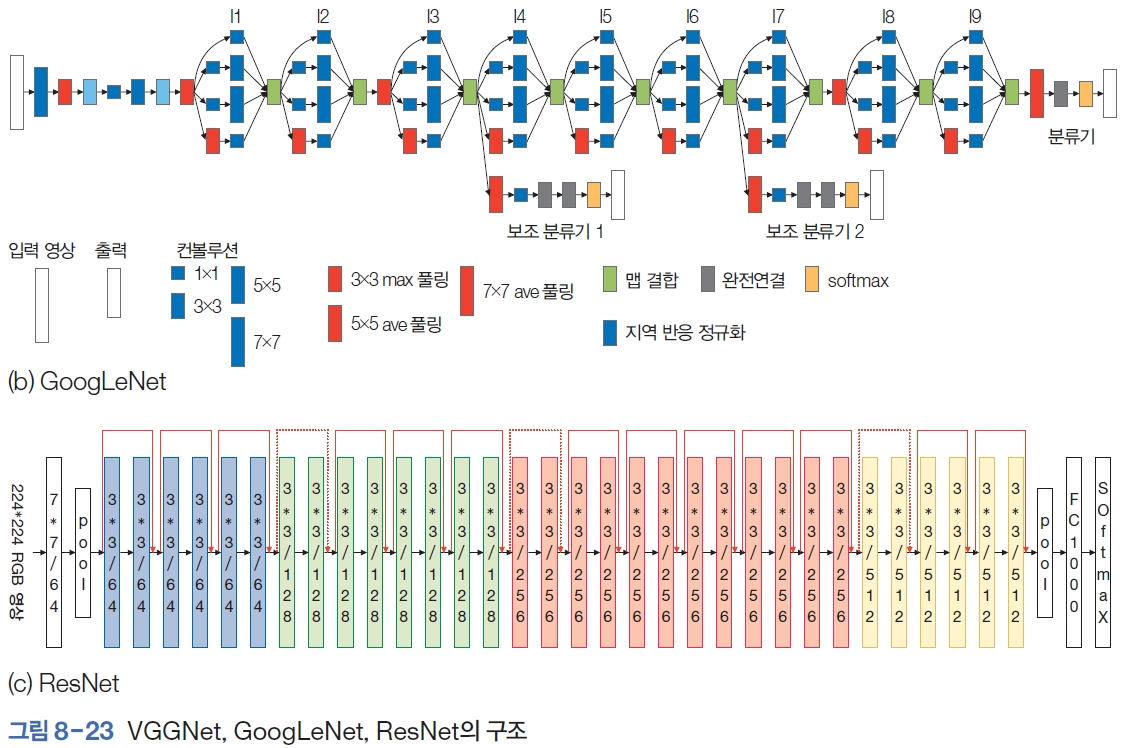

In [27]:
Image("그림 8-23(2).jpg", width=720)

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torchvision import models  # Pytorch 에서 제공하는 공개 모델들 

# 1. 사전 학습된 모델 로드 (Foundation Model 역할)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. 마지막 레이어 수정 (Fine-tuning 대상)
# ResNet18의 마지막 fc 레이어 입력 노드 수를 가져옴
num_ftrs = model.fc.in_features
# CIFAR-10 클래스 수인 10으로 교체 (이 레이어만 requires_grad가 True가 됨)
#model.fc = nn.Linear(num_ftrs, 10)
# FC 두개 로 확장 
model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
)

In [33]:
# 1. 디바이스 설정 및 데이터 준비
# ResNet은 224x224 입력을 기본으로 하지만, CIFAR의 32x32를 그대로 써도 동작은 합니다.
# 다만, 성능을 위해 70x70 정도로 Resize하는 전처리를 추가하는 것이 일반적입니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((70, 70)), # ResNet 성능을 위해 약간 키움
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) # ImageNet 통계값
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)


Files already downloaded and verified
Files already downloaded and verified


In [34]:
model = model.to(device)

# 5. 손실 함수 및 Optimizer
criterion = nn.CrossEntropyLoss()
# 학습 대상은 모든 파라미터들뿐입니다.
#optimizer = optim.Adam(model.parameters(), lr=0.0001)
# [수정] requires_grad가 True로 설정된 모든 파라미터(layer4 + fc)를 리스트로 추출하여 전달
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=0.0001)


# 6. 학습 
print("Starting Transfer Learning Training...")
model.train()
for epoch in range(5):  # 시간 관계상 3회만 수행
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f'[Epoch {epoch + 1}, Step {i + 1}] loss: {loss.item():.3f}')

print("Finished Training")

Starting Transfer Learning Training...
[Epoch 1, Step 100] loss: 0.657
[Epoch 1, Step 200] loss: 0.414
[Epoch 1, Step 300] loss: 0.301
[Epoch 1, Step 400] loss: 0.475
[Epoch 1, Step 500] loss: 0.525
[Epoch 1, Step 600] loss: 0.448
[Epoch 1, Step 700] loss: 0.222
[Epoch 2, Step 100] loss: 0.314
[Epoch 2, Step 200] loss: 0.267
[Epoch 2, Step 300] loss: 0.390
[Epoch 2, Step 400] loss: 0.141
[Epoch 2, Step 500] loss: 0.263
[Epoch 2, Step 600] loss: 0.388
[Epoch 2, Step 700] loss: 0.056
[Epoch 3, Step 100] loss: 0.023
[Epoch 3, Step 200] loss: 0.179
[Epoch 3, Step 300] loss: 0.031
[Epoch 3, Step 400] loss: 0.030
[Epoch 3, Step 500] loss: 0.074
[Epoch 3, Step 600] loss: 0.162
[Epoch 3, Step 700] loss: 0.036
[Epoch 4, Step 100] loss: 0.077
[Epoch 4, Step 200] loss: 0.056
[Epoch 4, Step 300] loss: 0.081
[Epoch 4, Step 400] loss: 0.016
[Epoch 4, Step 500] loss: 0.024
[Epoch 4, Step 600] loss: 0.019
[Epoch 4, Step 700] loss: 0.056
[Epoch 5, Step 100] loss: 0.010
[Epoch 5, Step 200] loss: 0.034
[

In [35]:
# 7. 테스트 성능 확인
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of Transfer Learning: {100 * correct / total:.2f}%')

Accuracy of Transfer Learning: 90.75%


## Fine-tunning (전체 파라메터 학습)

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# 1. 디바이스 설정 및 데이터 준비
# ResNet은 224x224 입력을 기본으로 하지만, CIFAR의 32x32를 그대로 써도 동작은 합니다.
# 다만, 성능을 위해 70x70 정도로 Resize하는 전처리를 추가하는 것이 일반적입니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.Resize((70, 70)), # ResNet 성능을 위해 약간 키움
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) # ImageNet 통계값
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

# 2. 사전 학습된 ResNet18 로드
# IMAGENET1K_V1 가중치를 사용하여 이미 사물 인식 능력이 있는 모델을 가져옵니다.
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 3. 모델의 모든 파라미터를 고정 (Frozen)
# 기본적으로 모든 층의 미분(gradient) 계산을 꺼서 학습이 안 되게 만듭니다.
for param in model.parameters():    
    param.requires_grad = True

# 4. 마지막 레이어(FC Layer) 교체
# ResNet18의 마지막 층(fc)을 우리 문제(10개 클래스)에 맞게 새로 정의합니다.
# 새로 생성된 nn.Linear는 기본적으로 requires_grad=True 상태입니다.
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10) 

model = model.to(device)

# 5. 손실 함수 및 Optimizer
criterion = nn.CrossEntropyLoss()
# 학습 대상은 모든 파라미터들뿐입니다.
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 6. 학습 
print("Starting Transfer Learning Training...")
model.train()
for epoch in range(5):  # 시간 관계상 3회만 수행
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print(f'[Epoch {epoch + 1}, Step {i + 1}] loss: {loss.item():.3f}')

print("Finished Training")

Files already downloaded and verified
Files already downloaded and verified
Starting Transfer Learning Training...
[Epoch 1, Step 100] loss: 0.681
[Epoch 1, Step 200] loss: 0.337
[Epoch 1, Step 300] loss: 0.484
[Epoch 1, Step 400] loss: 0.320
[Epoch 1, Step 500] loss: 0.326
[Epoch 1, Step 600] loss: 0.292
[Epoch 1, Step 700] loss: 0.548
[Epoch 2, Step 100] loss: 0.093
[Epoch 2, Step 200] loss: 0.177
[Epoch 2, Step 300] loss: 0.128
[Epoch 2, Step 400] loss: 0.145
[Epoch 2, Step 500] loss: 0.128
[Epoch 2, Step 600] loss: 0.134
[Epoch 2, Step 700] loss: 0.215
[Epoch 3, Step 100] loss: 0.014
[Epoch 3, Step 200] loss: 0.142
[Epoch 3, Step 300] loss: 0.086
[Epoch 3, Step 400] loss: 0.170
[Epoch 3, Step 500] loss: 0.098
[Epoch 3, Step 600] loss: 0.029
[Epoch 3, Step 700] loss: 0.174
[Epoch 4, Step 100] loss: 0.100
[Epoch 4, Step 200] loss: 0.025
[Epoch 4, Step 300] loss: 0.076
[Epoch 4, Step 400] loss: 0.022
[Epoch 4, Step 500] loss: 0.132
[Epoch 4, Step 600] loss: 0.059
[Epoch 4, Step 700] l

In [21]:
# 7. 테스트 성능 확인
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of Transfer Learning: {100 * correct / total:.2f}%')

Accuracy of Transfer Learning: 90.24%


### 끝